#### Проверим гипотезу 1: Перемещение ленты с "платными" элементами вверх списка увеличит конверсию перехода по платным элементам

H0: Перемещение ленты с "платными" элементами вверх списка не изменит конверсию.

H1: Перемещение ленты с "платными" элементами вверх списка увеличит конверсию.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# читаем файл с результатами эксперимента
df2 = pd.read_excel('marketpele_ab_test.xlsx')

Проведем предварительный анализ данных

In [2]:
print(df2.head(5))

df2.info()

        date  publisher_id platform group_name  pageviews  visible_pageviews  \
0 2019-03-01           101  Desktop          A      16580               5418   
1 2019-03-01           101  Desktop          B      16191               4906   
2 2019-03-01           106  Desktop          A      16227              11395   
3 2019-03-01           106  Desktop          B      15060              10369   
4 2019-03-01           106   Mobile          A      30494               7715   

   sessions  revenue  sponsord_clicks  organic_clicks  
0     12684  34.5201              300             849  
1     12717  32.9211              268             555  
2     11750  20.1620              601            2425  
3     11967  19.7429              663            1194  
4     22843  82.9329              456            1600  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------            

В данных 9 колонок: date, publisher_id, platform, group_name, pageviews, visible_pageviews, sessions, revenue, sponsord_clicks, organic_clicks. Пропусков нет.

Проверим колонку group_name.

In [3]:
df2['group_name'].value_counts() 

group_name
A    63
B    63
Name: count, dtype: int64

Колонка variant_name содержит 2 значения: B и A, что соответсвует тестовой и контрольной группам.

Проверим распределение данных на нормальность

In [15]:
# Проверим на нормальность
from statsmodels.stats.diagnostic import lilliefors

s, p = lilliefors(df2['sponsord_clicks'], dist='norm')
print(f'Данные распределены {"нормально" if p > 0.05 else "не нормально"}')

Данные распределены не нормально


Посмотрим на данные.

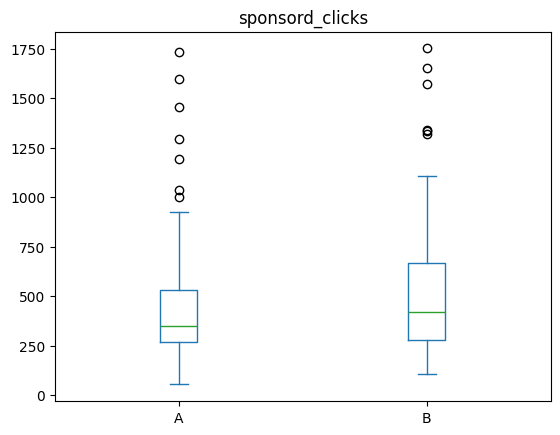

In [6]:
# Посмотрим на графики
import matplotlib.pyplot as plt
# %matplotlib inline

df2.plot(kind='box', column='sponsord_clicks', by='group_name');

Проверим гипотезу что конверсия sponsord_clicks не отличается

Альтернативная гипотеза - в группе B конверсия выше чем в группе A

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05

# количество кликов по платным элементам
payd_clicks = np.array([df2[df2.group_name=='A']['sponsord_clicks'].sum(), df2[df2.group_name=='B']['sponsord_clicks'].sum()])

# общее количество кликов
num_clicks = np.array([df2[df2.group_name=='A']['sponsord_clicks'].sum() + df2[df2.group_name=='A']['organic_clicks'].sum(), df2[df2.group_name=='B']['sponsord_clicks'].sum() + df2[df2.group_name=='B']['organic_clicks'].sum() ])

# Выполним Z-тест пропорций, альтернатива: пропорция кликов в группе А меньше чем в группе B
z_stat, p_value = proportions_ztest(payd_clicks, num_clicks, alternative='smaller')

print(f'p-value = {p_value}')

if p_value > alpha:
    print('Группы стат значимо не отличаются. Нельзя отвергнуть нулевую гипотезу.')
else:
    print('Отличие в группах статистически значимо. Отвергаем нулевую гипотезу в пользу альтернативной.')

# Посмотрим на конверсию
cr_a = payd_clicks[0] / num_clicks[0]
cr_b = payd_clicks[1] / num_clicks[1]

print(f"Конверсия перехода по платным элементам в группе A: {cr_a*100:.2f}%")
print(f"Конверсия перехода по платным элементам в группе B: {cr_b*100:.2f}%")

p-value = 0.0
Отличие в группах статистически значимо. Отвергаем нулевую гипотезу в пользу альтернативной.
Конверсия перехода по платным элементам в группе A: 22.57%
Конверсия перехода по платным элементам в группе B: 40.45%


Вывод. Тестирование выявило статистически значимое различие конверсии payd CTR. 

Конверсия перехода по платным элементам в тестовой группе - 40.45%, существенно лучше чем в контрольной - 22,57%